1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense


2.1 Creating Datasets

In [2]:
# Generate 2000 non-linear samples
X, y = make_moons(
    n_samples=2000,
    noise=0.12,
    random_state=42
)

# Create DataFrame in the same format as your image
df = pd.DataFrame({
    'X': X[:, 0],
    'Y': X[:, 1],
    'Class': y.astype(float)
})

df.head()

,X,Y,Class
0,1.750613,0.215969,1.0
1,0.388455,0.937320,0.0
2,0.494370,-0.308781,1.0
3,-0.947407,0.137360,0.0
4,0.504882,-0.348035,1.0


2.2 Visualize the Dataset

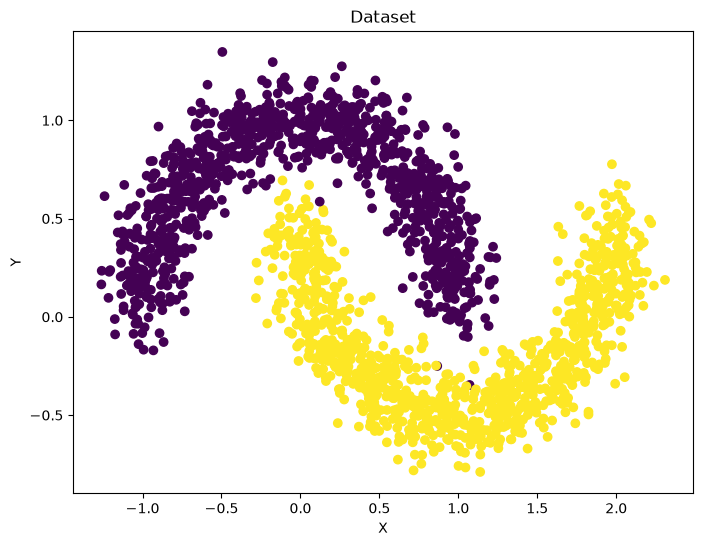

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['X'],
    df['Y'],
    c=df['Class']
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dataset')
plt.show()

3. Separate Features and Target

In [4]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 2)
y shape: (2000,)


4. Create Neural Network with ReLU

In [5]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

e:\DL_by_CompusX\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5. Model Summary

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

6. Check Initial Weights

In [7]:
model.get_weights()

[array([[-0.40887272, -0.6083569 ,  2.2601008 ,  0.02581356,  0.25962186,
         -0.13237444, -1.8976018 ,  0.8253193 ,  0.8009093 , -0.6367088 ],
        [ 0.02404197, -0.9004054 , -1.8384502 , -0.22594288, -0.74261856,
         -0.48796248,  0.2517802 , -0.4617239 ,  0.40610892, -0.97725815]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.2815227 ,  0.28636417,  0.1942202 , -0.21673931,  0.40723467,
         -0.33014712,  0.3816886 ,  0.12374786,  0.02967692, -0.66001904],
        [ 0.12773986, -0.02339001,  0.00320319,  0.27026108,  0.70423365,
         -0.3357765 ,  0.47856742,  0.46262035,  0.4097959 ,  0.25196496],
        [ 0.71192765, -0.62905854,  0.49347943,  0.90125835, -0.06178535,
         -0.02614209,  0.47163874, -0.14996275,  0.2406175 ,  0.38855487],
        [-0.38125372, -0.5071896 , -0.35250244, -0.1211282 , -0.36573386,
          0.5773045 , -0.47654235, -0.1781086 ,  0.27727544,  0.04422824],
        [-0.30095

7. Store the Weights

In [8]:
initial_weights = model.get_weights()

8. Random Weight Initialization with Zero Bias Initialization

In [9]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

9. Set the Initialized Weights and Biases in the Model

In [12]:
model.set_weights(initial_weights)

In [13]:
model.get_weights()

[array([[-0.26417327, -1.1470286 ,  1.0526481 ,  0.17852192, -0.55880827,
          1.301924  ,  0.4169556 , -0.7373187 , -0.17876326, -0.4938889 ],
        [ 0.09540406, -0.57582456,  0.5573677 , -0.07710699,  0.07830043,
          0.28889352, -1.2191361 , -2.3504963 , -0.23198968,  0.44878018]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.05670161, -0.09071264,  0.38692522,  0.02520452, -0.27234077,
          0.02787894,  0.24146819, -0.27552718,  0.33415   , -0.1540729 ],
        [ 0.08188437,  0.27749565,  0.32189322,  0.26716036, -0.5759092 ,
         -0.07239945,  0.38214517,  0.6536201 ,  0.25638828, -0.18774313],
        [ 0.3273649 ,  0.08457983, -0.06691731,  0.00317746, -0.00975688,
          0.28241408, -0.02042175,  0.06927054,  0.02534209, -0.64145356],
        [-0.20113285,  0.35157317,  0.56336075, -0.12408717,  0.12299062,
         -0.15678057, -0.21540892, -0.1353343 , -0.01587799, -0.01111477],
        [-0.09723

10. Compile the Model

In [14]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

11. Train the Model

In [15]:
history = model.fit(
    X,
    y,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5681 - loss: 0.6347 - val_accuracy: 0.7050 - val_loss: 0.5774
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6994 - loss: 0.5701 - val_accuracy: 0.7575 - val_loss: 0.4969
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7981 - loss: 0.4937 - val_accuracy: 0.8575 - val_loss: 0.4260
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8656 - loss: 0.4447 - val_accuracy: 0.8800 - val_loss: 0.3964
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8775 - loss: 0.4228 - val_accuracy: 0.8900 - val_loss: 0.3800
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8888 - loss: 0.4049 - val_accuracy: 0.8950 - val_loss: 0.3667
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8994 - loss: 0.3909 - val_accuracy: 0.9000 - val_loss: 0.3540
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9031 - loss: 0.3766 - val_accuracy: 0.9025 - v

12. Check the Weights After Training

In [16]:
model.get_weights()

[array([[-0.15267459, -1.2998983 ,  1.1008502 ,  0.2885092 , -1.0097015 ,
          1.4232416 ,  0.49665558, -0.4746361 , -0.24855575, -0.63230634],
        [ 0.2933571 , -0.996282  ,  0.6615217 , -0.00967464,  0.18500699,
          0.4444287 , -1.3425727 , -2.2432475 , -0.302029  ,  0.7124122 ]],
       dtype=float32),
 array([ 0.4191726 , -0.06009042, -0.17599055, -0.22379068, -0.06604201,
        -0.14281838, -0.04532089,  0.47682062,  0.57263273, -0.19355169],
       dtype=float32),
 array([[ 4.48915571e-01, -7.42764831e-01,  5.09509444e-01,
         -3.41541260e-01,  4.83070016e-02,  5.57842314e-01,
          1.97329611e-01, -3.04951012e-01,  6.19004309e-01,
          1.18977092e-01],
        [-9.33773518e-02,  1.48150176e-01,  5.79959512e-01,
          1.62449237e-02,  3.54750566e-02, -1.57583097e-04,
          5.96355855e-01,  7.73763955e-01, -1.29163086e-01,
         -5.25086105e-01],
        [ 1.67237788e-01,  1.41776085e-01,  4.02330868e-02,
          4.21240181e-03,  5.43093

13. Check the Predictions

In [17]:
predictions = model.predict(X, verbose=0)

predictions[:10]

array([[9.9987912e-01],
       [8.9175024e-05],
       [9.9999976e-01],
       [2.7096316e-06],
       [9.9999988e-01],
       [1.0000000e+00],
       [8.5796719e-06],
       [9.9999887e-01],
       [5.7755595e-05],
       [9.9999952e-01]], dtype=float32)

14. Plot Training Loss

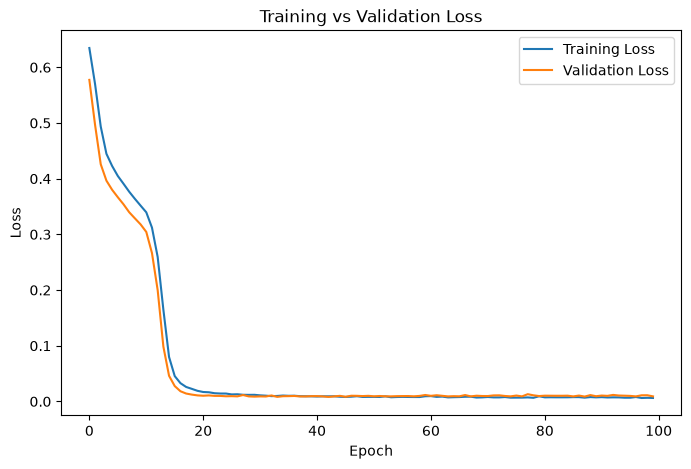

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()

15. Plot Accuracy

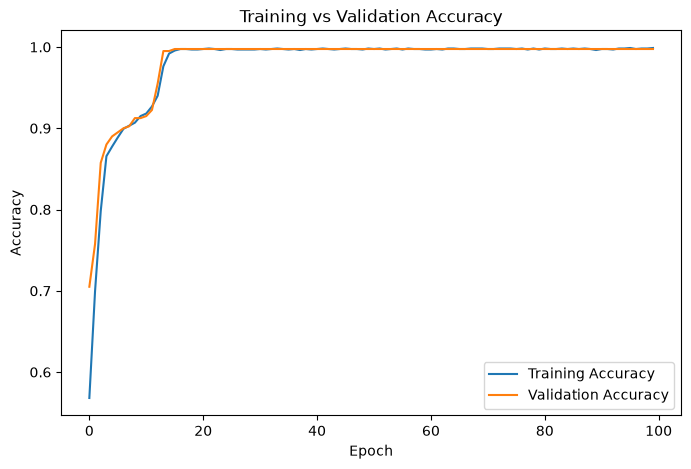

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

16. Decision Boundary

In [20]:
from mlxtend.plotting import plot_decision_regions

class MyModel:

    def __init__(self, model):
        self.model = model

    def predict(self, X):
        pred = self.model.predict(
            X,
            verbose=0
        )

        return (
            pred >= 0.5
        ).astype(int).ravel()

17. Create Classifier

In [21]:
clf = MyModel(model)

18. Plot Decision Regions

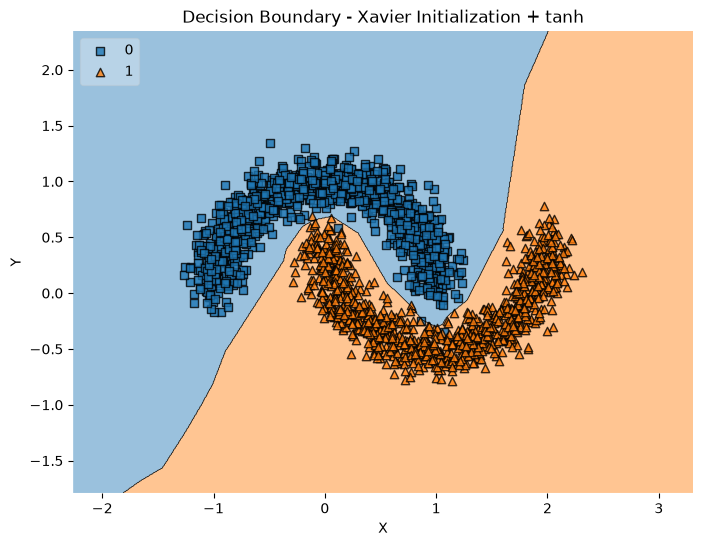

In [22]:
plt.figure(figsize=(8, 6))

plot_decision_regions(
    X,
    y.astype(int),
    clf=clf,
    legend=2
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Decision Boundary - Xavier Initialization + tanh')

plt.show()

In [ ]:
(np.random.randn(10,10)*0.01).min()

In [ ]:
(np.random.randn(10,10)*0.01).max()